In [1]:
from google.colab import files

uploaded = files.upload()

Saving loan_approval.csv to loan_approval (1).csv


In [21]:
import pandas as pd
print("Ishan Adhikari")
df = pd.read_csv("loan_approval.csv")
df.head()

Ishan Adhikari


,ApplicantID,Age,Income,CreditScore,EmploymentYears,LoanAmount,Approved
0,A001,25,30000,650,2,15000,No
1,A002,35,75000,750,8,50000,Yes
2,A003,45,95000,800,15,80000,Yes
3,A004,22,25000,580,1,10000,No
4,A005,40,85000,780,12,60000,Yes


In [22]:
# Display dataset information
print("Ishan Adhikari")
print("\nDataset Information:")
print(df.info())


Ishan Adhikari

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ApplicantID      30 non-null     object
 1   Age              30 non-null     int64 
 2   Income           30 non-null     int64 
 3   CreditScore      30 non-null     int64 
 4   EmploymentYears  30 non-null     int64 
 5   LoanAmount       30 non-null     int64 
 6   Approved         30 non-null     object
dtypes: int64(5), object(2)
memory usage: 1.8+ KB
None


In [23]:

print(df.columns)

Index(['ApplicantID', 'Age', 'Income', 'CreditScore', 'EmploymentYears',
       'LoanAmount', 'Approved'],
      dtype='object')


In [24]:
# Distribution of loan approval:
print("Ishan Adhikari")
print("\nLoan Approval Distribution:")
print(df["Approved"].value_counts())


Ishan Adhikari

Loan Approval Distribution:
Approved
Yes    20
No     10
Name: count, dtype: int64


In [25]:
# Percentage distribution:
print("Ishan Adhikari")
print("\nLoan Approval Percentage:")
print(df["Approved"].value_counts(normalize=True) * 100)


Ishan Adhikari

Loan Approval Percentage:
Approved
Yes    66.666667
No     33.333333
Name: proportion, dtype: float64


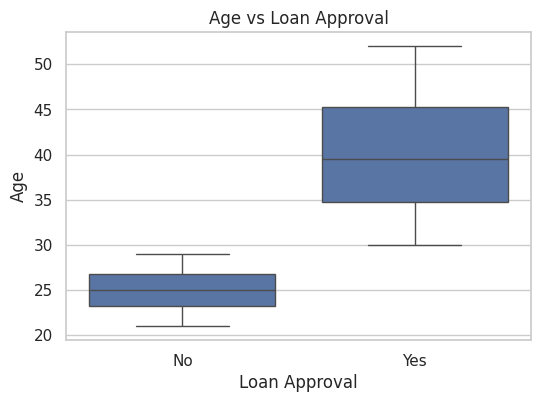

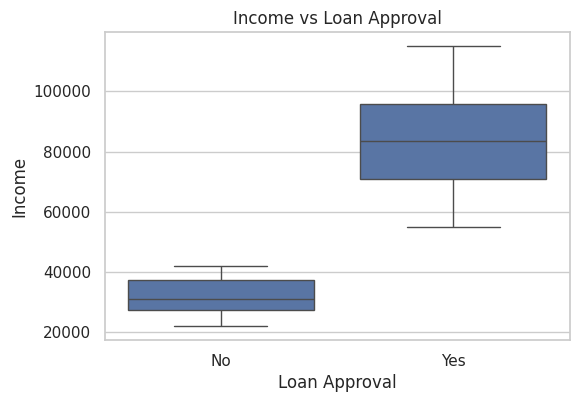

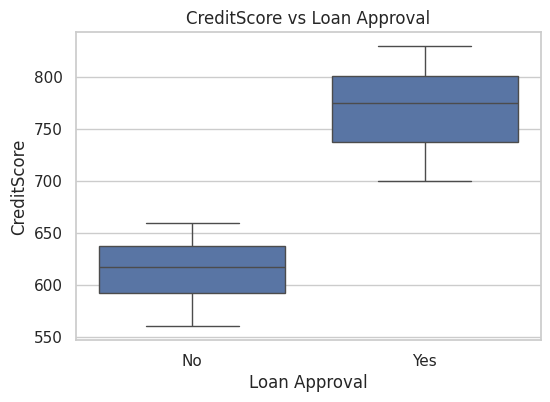

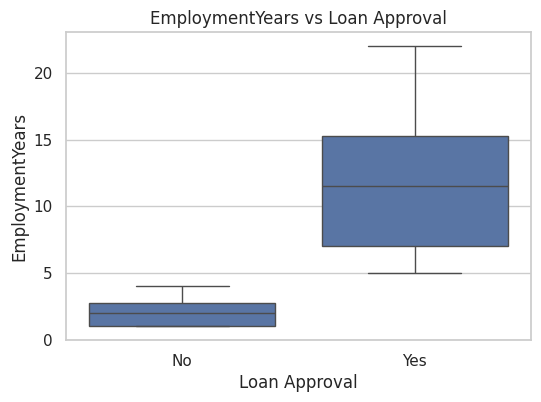

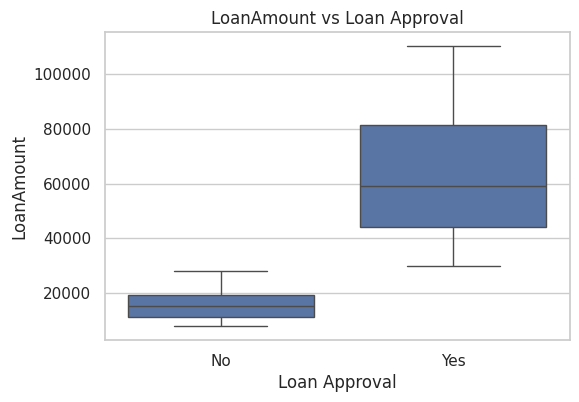

In [26]:

import matplotlib.pyplot as plt
import seaborn as sns



# Set plot style
sns.set(style="whitegrid")

# List of numerical features
features = ['Age', 'Income', 'CreditScore', 'EmploymentYears', 'LoanAmount']

# Create boxplots
for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Approved', y=feature, data=df)
    plt.title(f'{feature} vs Loan Approval')
    plt.xlabel('Loan Approval')
    plt.ylabel(feature)
    plt.show()

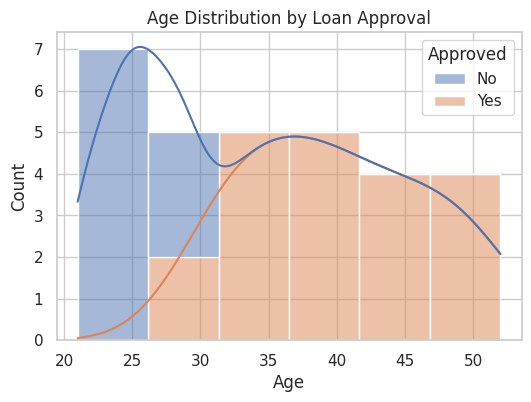

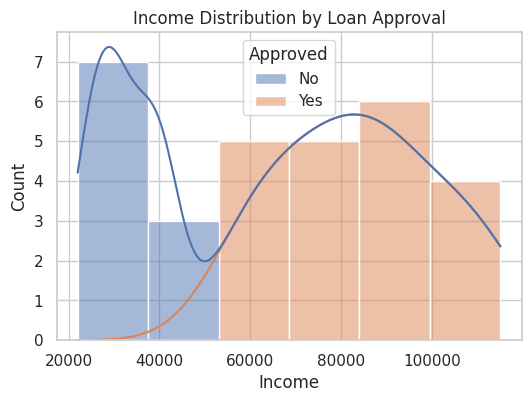

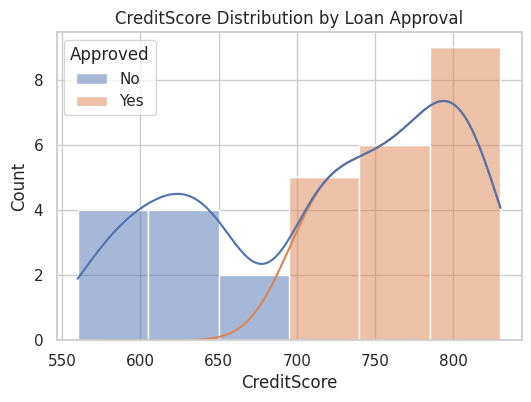

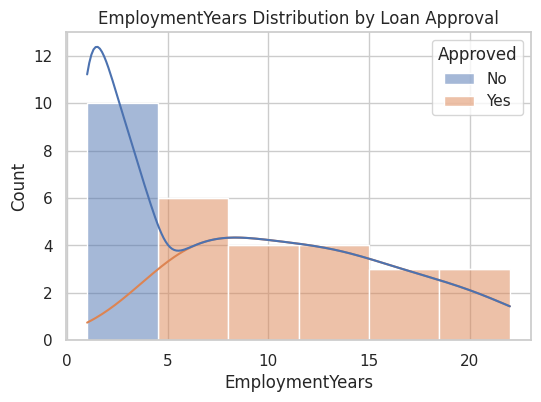

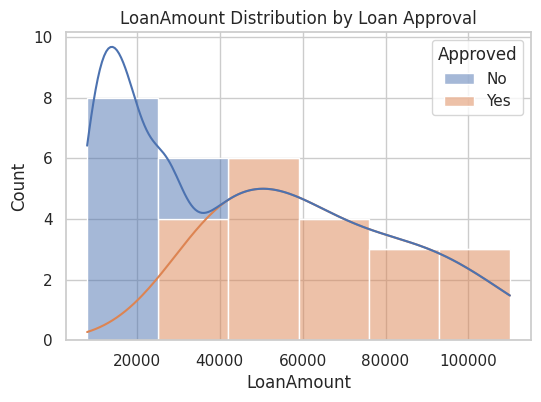

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['Age', 'Income', 'CreditScore', 'EmploymentYears', 'LoanAmount']

for feature in features:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=feature, hue='Approved', kde=True, multiple='stack')
    plt.title(f'{feature} Distribution by Loan Approval')
    plt.show()

In [28]:
# Encode Approved column
print("Ishan Adhikari")
df['Approved'] = df['Approved'].map({'Yes': 1, 'No': 0})

# Drop ApplicantID column
df = df.drop('ApplicantID', axis=1)

# Display updated dataset
print(df.head())

# Check data types
print("\nDataset Information:")
print(df.info())


Ishan Adhikari
   Age  Income  CreditScore  EmploymentYears  LoanAmount  Approved
0   25   30000          650                2       15000         0
1   35   75000          750                8       50000         1
2   45   95000          800               15       80000         1
3   22   25000          580                1       10000         0
4   40   85000          780               12       60000         1

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              30 non-null     int64
 1   Income           30 non-null     int64
 2   CreditScore      30 non-null     int64
 3   EmploymentYears  30 non-null     int64
 4   LoanAmount       30 non-null     int64
 5   Approved         30 non-null     int64
dtypes: int64(6)
memory usage: 1.5 KB
None


In [31]:
from sklearn.model_selection import train_test_split
print("Ishan Adhikari")
# Separate features and target
X = df.drop('Approved', axis=1)
y = df['Approved']

# Split data into 75% training and 25% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Display the shapes of datasets
print("Training feature set:", X_train.shape)
print("Testing feature set:", X_test.shape)
print("Training target set:", y_train.shape)
print("Testing target set:", y_test.shape)

Ishan Adhikari
Training feature set: (22, 5)
Testing feature set: (8, 5)
Training target set: (22,)
Testing target set: (8,)


In [32]:
from sklearn.tree import DecisionTreeClassifier
print("Ishan Adhikari")
# Create Decision Tree model
dt_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Ishan Adhikari
Decision Tree model trained successfully!


In [33]:
print("Ishan Adhikari")
print("Tree Depth:", dt_model.get_depth())
print("Number of Nodes:", dt_model.tree_.node_count)

Ishan Adhikari
Tree Depth: 1
Number of Nodes: 3


Ishan Adhikari
Model Accuracy: 1.0
Accuracy Percentage: 100.0 %

Confusion Matrix:
[[3 0]
 [0 5]]


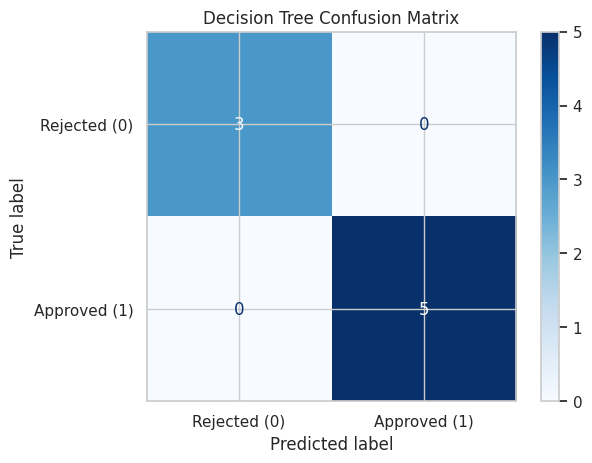

In [35]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
print("Ishan Adhikari")
# Make predictions on test data
y_pred = dt_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Rejected (0)", "Approved (1)"]
)

disp.plot(cmap="Blues")

plt.title("Decision Tree Confusion Matrix")
plt.show()

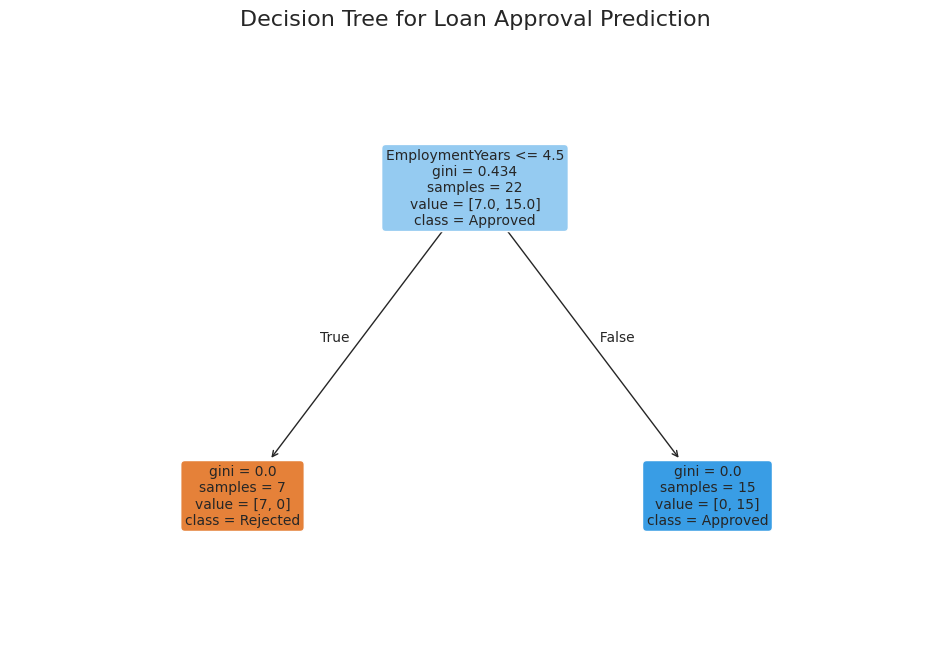

In [36]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(12, 8))

# Plot decision tree
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["Rejected", "Approved"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree for Loan Approval Prediction", fontsize=16)
plt.show()